In [1]:
import pandas as pd

# Load dataset
file_path = 'StudentsPerformance_3_lyst1729690388778.csv'
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

# Display dataset information
print(df.info())

# Display column names
print(df.columns)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

In [2]:
print(df.shape)

(1000, 8)


In [3]:
print(df.dtypes)

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [4]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [5]:
print(df.duplicated().sum())

0


In [6]:
print(df.describe())

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [7]:
for column in df.columns:
    print(column)
    print(df[column].unique())

gender
['female' 'male']
race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch
['standard' 'free/reduced']
test preparation course
['none' 'completed']
math score
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
reading score
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]
writing score
[ 74  88  93  44  75  78  92 

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

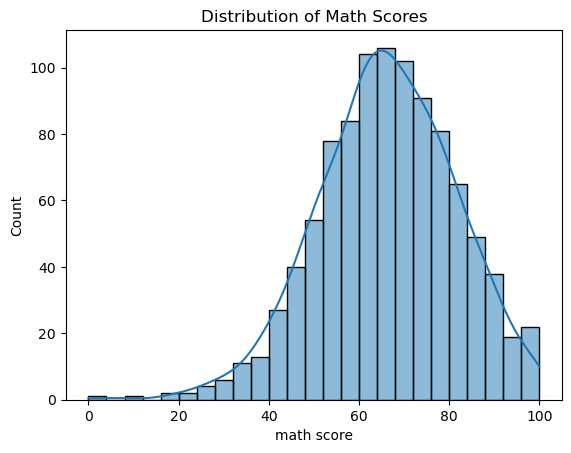

In [9]:
sns.histplot(df['math score'], kde=True)
plt.title('Distribution of Math Scores')
plt.show()

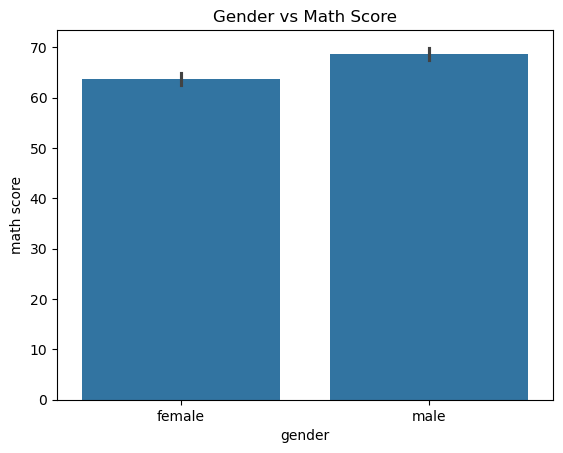

In [10]:
sns.barplot(x='gender', y='math score', data=df)
plt.title('Gender vs Math Score')
plt.show()

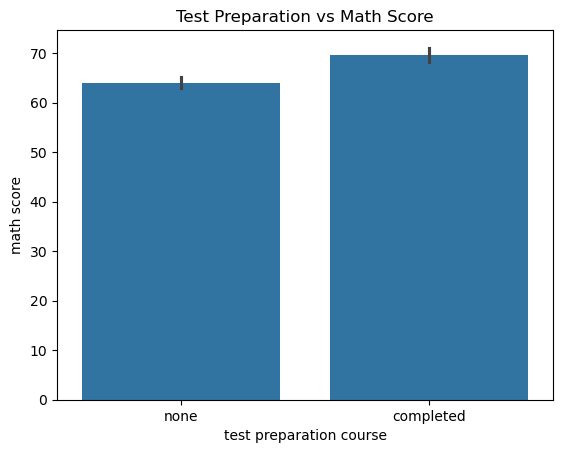

In [11]:
sns.barplot(x='test preparation course', y='math score', data=df)
plt.title('Test Preparation vs Math Score')
plt.show()

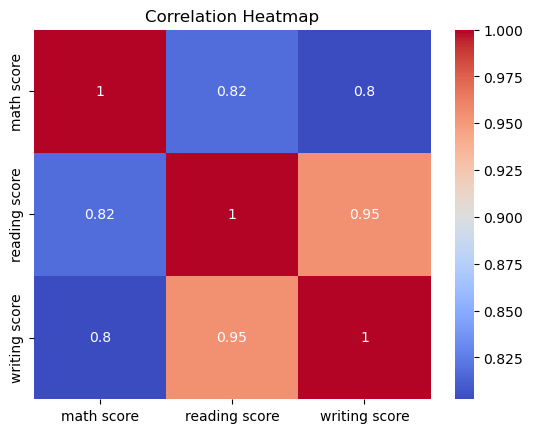

In [12]:
numeric_df = df[['math score', 'reading score', 'writing score']]

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
X = df.drop('math score', axis=1)
y = df['math score']

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), categorical_features)
    ],
    remainder='passthrough'
)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

In [17]:
from sklearn.pipeline import Pipeline

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor())
])

rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])

knn_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [22]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return mae, mse, rmse, r2

In [24]:
models = {
    'Linear Regression': lr_model,
    'Random Forest': rf_model,
    'KNN': knn_model
}

for name, model in models.items():
    mae, mse, rmse, r2 = evaluate_model(model, X_test, y_test)

    print(f'Model: {name}')
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'R2 Score: {r2}')
    print('---------------------------')

Model: Linear Regression
MAE: 4.214763142474853
MSE: 29.095169866715523
RMSE: 5.393993869732846
R2 Score: 0.8804332983749563
---------------------------
Model: Random Forest
MAE: 4.789716666666666
MSE: 38.085429833333336
RMSE: 6.171339387307534
R2 Score: 0.8434877938158
---------------------------
Model: KNN
MAE: 6.287999999999999
MSE: 63.172000000000004
RMSE: 7.948081529526481
R2 Score: 0.7403944465813862
---------------------------


In [25]:
sample_data = pd.DataFrame({
    'gender': ['female'],
    'race/ethnicity': ['group B'],
    'parental level of education': ["bachelor's degree"],
    'lunch': ['standard'],
    'test preparation course': ['completed'],
    'reading score': [72],
    'writing score': [74]
})

prediction = rf_model.predict(sample_data)

print('Predicted Math Score:', prediction[0])

Predicted Math Score: 68.33
